
# Лабораторная работа №4 — транскрибирование музыки

В ноутбуке реализованы все три части задания:

1. собственная реализация **ДПФ**;
2. собственная реализация **КВПФ (STFT)** через ранее написанный ДПФ;
3. анализ файла `6413-26.wav`, построение спектрограммы и приближённая транскрипция мелодии.

Ноутбук сделан так, чтобы его можно было запустить по порядку сверху вниз.



## 1. Импорт библиотек и исходные функции

Ниже я перенёс заготовку в формат ноутбука и реализовал недостающие части.


In [31]:

import unittest
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import fft
from scipy.io import wavfile
from scipy.signal import stft


In [32]:

def dft(x: np.ndarray) -> np.ndarray:
    """Собственная реализация дискретного преобразования Фурье."""
    x = np.asarray(x, dtype=np.complex128)
    n = x.shape[0]
    k = np.arange(n).reshape(-1, 1)
    m = np.arange(n).reshape(1, -1)
    W = np.exp(-2j * np.pi * k * m / n)
    return W @ x


def real_stft(x: np.ndarray, segment: int, overlap: int) -> np.ndarray:
    """Собственная реализация STFT для вещественного сигнала.

    Поведение согласовано с scipy.signal.stft(..., boundary=None,
    padded=False, window="boxcar"), но без встроенных fft/stft.
    """
    x = np.asarray(x, dtype=float)
    n = x.shape[0]
    assert len(x.shape) == 1
    assert segment < n
    assert overlap < segment

    step = segment - overlap
    frames_count = 1 + (n - segment) // step
    result = np.empty((segment // 2 + 1, frames_count), dtype=np.complex128)

    for i in range(frames_count):
        start = i * step
        frame = x[start : start + segment]
        spectrum = dft(frame)
        result[:, i] = spectrum[: segment // 2 + 1]

    return result



## 2. Проверка через тесты

Сначала проверяем ДПФ, затем КВПФ.  
Во втором тесте сравнение идёт со `scipy.signal.stft`, но с учётом различия в нормировке.


In [33]:

class Test(unittest.TestCase):
    class Params:
        def __init__(self, n: int, segment: int, overlap: int) -> None:
            self.n = n
            self.segment = segment
            self.overlap = overlap

        def __str__(self) -> str:
            return f"n={self.n} segment={self.segment} overlap={self.overlap}"

    def test_dft(self) -> None:
        for n in (10, 11, 12, 13, 14, 15, 16):
            with self.subTest(n=n):
                np.random.seed(0)
                x = np.random.rand(n) + 1j * np.random.rand(n)
                actual = dft(x)
                expected = fft(x)
                self.assertTrue(np.allclose(actual, expected))

    def test_stft(self) -> None:
        params_list = (
            Test.Params(50, 10, 5),
            Test.Params(50, 10, 6),
            Test.Params(50, 10, 7),
            Test.Params(50, 10, 8),
            Test.Params(50, 10, 9),
            Test.Params(101, 15, 7),
            Test.Params(101, 15, 8),
        )

        for params in params_list:
            with self.subTest(params=str(params)):
                np.random.seed(0)
                x = np.random.rand(params.n)
                actual = real_stft(x, params.segment, params.overlap)
                _, _, expected = stft(
                    x,
                    boundary=None,
                    nperseg=params.segment,
                    noverlap=params.overlap,
                    padded=False,
                    window="boxcar",
                )
                self.assertTrue(np.allclose(actual, params.segment * expected))


suite = unittest.defaultTestLoader.loadTestsFromTestCase(Test)
unittest.TextTestRunner(verbosity=2).run(suite)


test_dft (__main__.Test.test_dft) ... ok
test_stft (__main__.Test.test_stft) ... ok

----------------------------------------------------------------------
Ran 2 tests in 0.018s

OK


<unittest.runner.TextTestResult run=2 errors=0 failures=0>


## 3. Загрузка аудиофайла

Считываем `6413-26.wav`. Файл стерео, поэтому для дальнейшего анализа переводим его в моно усреднением двух каналов.


In [34]:

wav_path = Path("6413-26.wav")
fs, x = wavfile.read(wav_path)

print("Частота дискретизации:", fs, "Гц")
print("Форма массива:", x.shape)
print("Тип данных:", x.dtype)

if x.ndim == 2:
    x_mono = x.mean(axis=1)
else:
    x_mono = x.astype(float)

x_mono = x_mono.astype(np.float64)
x_mono /= np.max(np.abs(x_mono))

duration = len(x_mono) / fs
print("Длительность:", round(duration, 3), "с")


Частота дискретизации: 44100 Гц
Форма массива: (373248, 2)
Тип данных: int16
Длительность: 8.464 с



## 4. Построение спектрограммы

По методичке в третьей части задания нужно использовать быструю библиотечную реализацию STFT и визуализировать квадрат модуля спектра.

Для музыкального сигнала удобно взять окно побольше, чтобы лучше различать частоты нот. Ниже использовано:

- `nperseg = 4096`
- `noverlap = 3584`
- окно `hann`

Так получается достаточно наглядная спектрограмма.


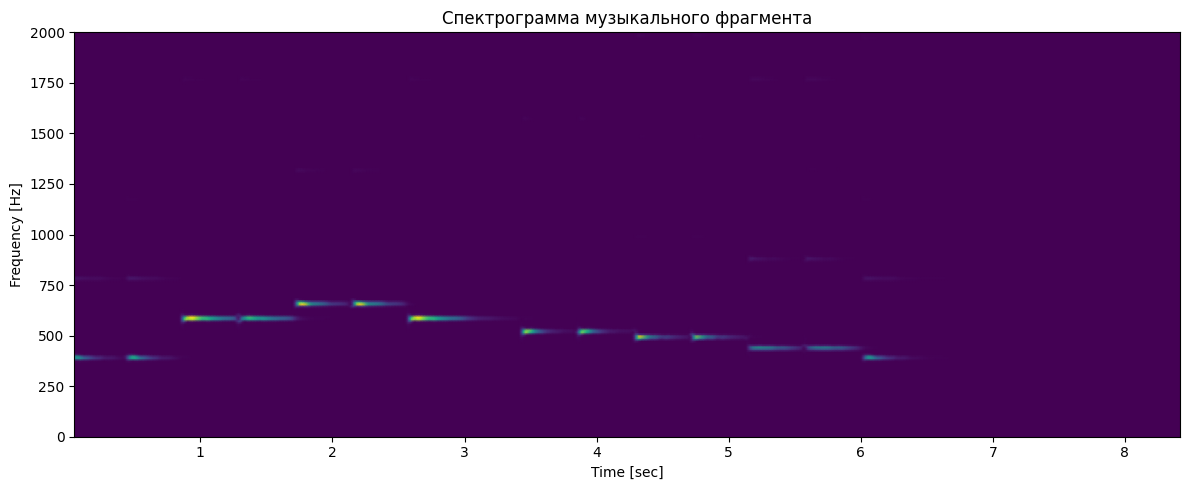

In [35]:

segment = 4096
overlap = 3584

f, t, spectrum = stft(
    x_mono,
    fs=fs,
    nperseg=segment,
    noverlap=overlap,
    boundary=None,
    padded=False,
    window="hann",
)

plt.figure(figsize=(12, 5))
plt.pcolormesh(t, f, np.abs(spectrum) ** 2, shading="gouraud")
plt.xlabel("Time [sec]")
plt.ylabel("Frequency [Hz]")
plt.ylim(0, 2000)
plt.title("Спектрограмма музыкального фрагмента")
plt.tight_layout()
plt.show()
